# 05 — Model explainability (SHAP)

## What this notebook does
Uses **SHAP** (SHapley Additive exPlanations) for tree models to show:
- **Global:** which environmental drivers matter most (mean |SHAP|)
- **Climate pathway:** how a climate variable changes predictions (dependence plot)

## Why SHAP
Water managers need **transparent** links between landscape/climate and chemistry. SHAP decomposes each prediction into **additive contributions** per feature, consistent with cooperative game theory (Shapley values).

## How to read plots
- **Summary bar:** average magnitude of impact across samples.
- **Dependence:** x-axis = feature value, y-axis = SHAP value → direction and nonlinearity of effect.


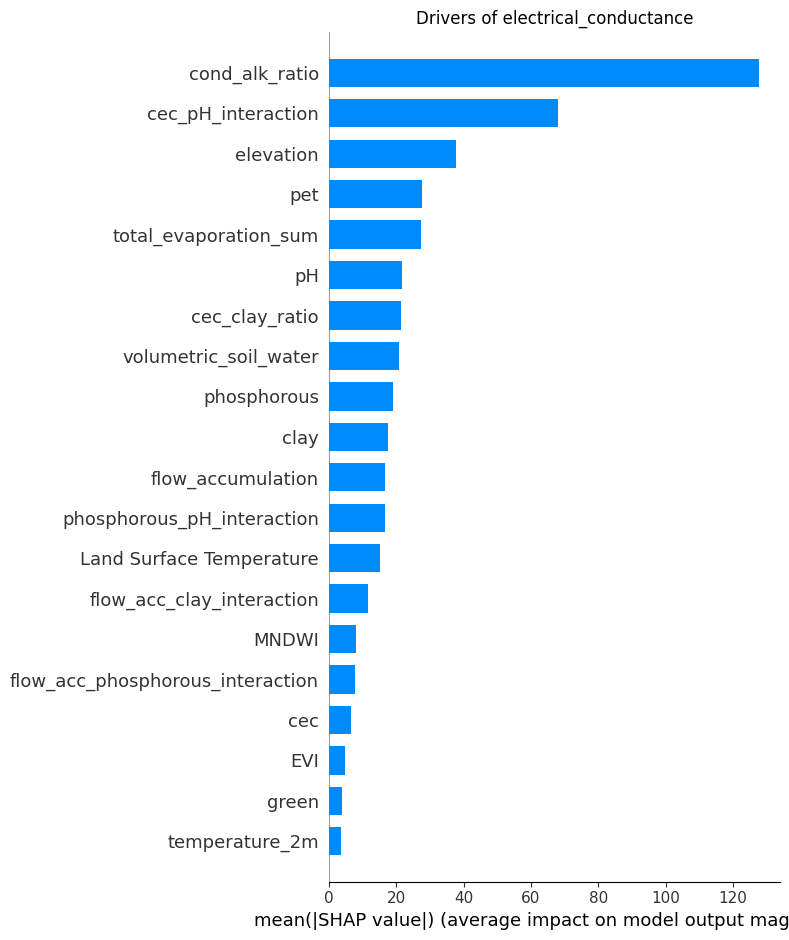

<Figure size 800x500 with 0 Axes>

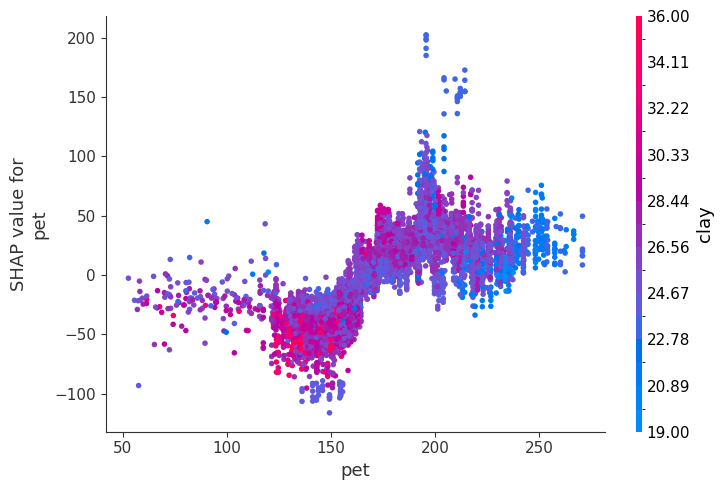

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().resolve()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent
import sys
sys.path.insert(0, str(ROOT))

import lightgbm as lgb
from src.features.preprocess import feature_columns, impute_median
from src.features.scientific_interactions import add_scientific_interactions
from src.models.explainability import shap_summary_bar, shap_dependence_climate

RAW = ROOT / "data" / "raw"
for name in ["water_quality_dataset_v1.csv", "water_quality.csv"]:
    csv_path = RAW / name
    if csv_path.exists():
        break
else:
    raise FileNotFoundError("No data/raw/water_quality_dataset_v1.csv or water_quality.csv found.")
df = pd.read_csv(csv_path)
df = add_scientific_interactions(df)
target = "electrical_conductance" if "electrical_conductance" in df.columns else df.select_dtypes(include="number").columns[-1]
y = df[target]
cols = feature_columns(df, exclude_targets=True)
X = df[cols].copy()
X, _ = impute_median(X)
model = lgb.LGBMRegressor(n_estimators=200, max_depth=8, random_state=42, verbose=-1)
model.fit(X, y)
fig_dir = ROOT / "figures"
fig_dir.mkdir(exist_ok=True)
shap_summary_bar(model, X, out_path=fig_dir / "shap_summary.png", title=f"Drivers of {target}")
plt.show()
climate_cols = [c for c in X.columns if any(k in c.lower() for k in ["pet","precip","temp","soil","evap"])]
if climate_cols:
    shap_dependence_climate(model, X, climate_cols[0], out_path=fig_dir / "shap_climate.png")
    plt.show()
